

**DQN CODES FOR THREE ENVIRONMENTS**




In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import pickle
import pandas as pd
import os
import math

In [3]:
class WarehouseRobotEnv(gym.Env):
    def __init__(self, stochastic=False):
        super(WarehouseRobotEnv, self).__init__()

        self.grid_size = 6  # 6x6 Grid
        self.obstacles = [(2, 2), (3, 3), (4, 1)]  # Fixed shelves
        self.pickup_location = (3, 2)
        self.dropoff_location = (5, 5)
        self.robot_position = (0, 0)  # Start position
        self.has_item = False  # Whether the robot has picked up an item
        self.stochastic = stochastic  # Determines environment randomness
        self.visited_positions = []  # Track visited positions

        # Load images
        self.robot_img = mpimg.imread("agent.jpg")
        self.pickup_img = mpimg.imread("pickup.jpg")
        self.dropoff_img = mpimg.imread("dropoff.jpg")
        self.obstacle_img = mpimg.imread("obstacles.jpg")
        # Define action space: [Up, Down, Left, Right, Pick-up, Drop-off]
        self.action_space = spaces.Discrete(6)

        # Observation space: (Position X, Position Y, Has item (0 or 1))
        self.observation_space = spaces.Tuple((
            spaces.Discrete(self.grid_size),
            spaces.Discrete(self.grid_size),
            spaces.Discrete(2)  # 0: No item, 1: Holding item
        ))

    def step(self, action):
        x, y = self.robot_position
        reward = -1  # Penalize steps for efficiency
        terminated = False
        truncated = False
        info = {}

        if action == 0:  # Up
            new_position = (x, y - 1)
        elif action == 1:  # Down
            new_position = (x, y + 1)
        elif action == 2:  # Left
            new_position = (x - 1, y)
        elif action == 3:  # Right
            new_position = (x + 1, y)
        elif action == 4 and self.robot_position == self.pickup_location and not self.has_item:
            self.has_item = True
            reward = 25
            new_position = self.robot_position
        elif action == 5 and self.robot_position == self.dropoff_location and self.has_item:
            reward = 100
            terminated = True
            new_position = self.robot_position
        else:
            new_position = self.robot_position

        # Ensure within bounds
        if new_position[0] < 0 or new_position[0] >= self.grid_size or new_position[1] < 0 or new_position[1] >= self.grid_size:
            new_position = self.robot_position  # No movement

        # Prevent moving into obstacles
        if new_position in self.obstacles:
            reward -= 20  # Penalty for hitting an obstacle
            new_position = self.robot_position

        # Stochastic environment: 10% chance of staying in place
        if self.stochastic and random.random() < 0.1:
            new_position = self.robot_position

        self.visited_positions.append(self.robot_position)  # Track visited positions
        self.robot_position = new_position
        observation = (*self.robot_position, int(self.has_item))


        return observation , reward, terminated, truncated, info

    def reset(self):
        self.robot_position = (0, 0)
        self.has_item = False
        self.visited_positions.clear()
        observation = (*self.robot_position, int(self.has_item))
        info = {}
        return observation, info

    def render(self):
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.set_xlim(-0.5, self.grid_size-0.5)
        ax.set_ylim(-0.5, self.grid_size-0.5)

        for ox, oy in self.obstacles:
            print("\n")
            ax.imshow(self.obstacle_img, extent=[ox-0.5, ox+0.5, oy-0.5, oy+0.5])

        if not self.has_item:
            ax.imshow(self.pickup_img, extent=[self.pickup_location[0]-0.5, self.pickup_location[0]+0.5, self.pickup_location[1]-0.5, self.pickup_location[1]+0.5])

        ax.imshow(self.dropoff_img, extent=[self.dropoff_location[0]-0.5, self.dropoff_location[0]+0.5, self.dropoff_location[1]-0.5, self.dropoff_location[1]+0.5])
        print("\n")
        ax.imshow(self.robot_img, extent=[self.robot_position[0]-0.5, self.robot_position[0]+0.5, self.robot_position[1]-0.5, self.robot_position[1]+0.5])
        print("\n")
        for pos in self.visited_positions:
            ax.add_patch(plt.Circle((pos[0], pos[1]), 0.2, color='blue', alpha=0.3))

        plt.grid(True)
        plt.title("Warehouse Robot Environment")
        plt.show()



In [6]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

# Q-Network architecture
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Experience Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.array, zip(*batch))
        return state, action, reward, next_state, done

    def __len__(self):
        return len(self.buffer)

# DQN Agent
class DQNAgent:
    def __init__(self, env, state_dim, action_dim, buffer_size=10000, batch_size=64, gamma=0.99, lr=1e-3,
                 epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01, target_update=10):
        self.env = env
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.batch_size = batch_size
        self.gamma = gamma
        self.lr = lr
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.target_update = target_update

        self.policy_net = DQN(state_dim, action_dim)
        self.target_net = DQN(state_dim, action_dim)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(buffer_size)
        self.steps_done = 0

    def select_action(self, state):
        if random.random() < self.epsilon:
            return self.env.action_space.sample()
        state = torch.tensor([state], dtype=torch.float32)
        with torch.no_grad():
            return self.policy_net(state).argmax().item()

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return

        state, action, reward, next_state, done = self.memory.sample(self.batch_size)
        state = torch.tensor(state, dtype=torch.float32)
        action = torch.tensor(action, dtype=torch.int64).unsqueeze(1)
        reward = torch.tensor(reward, dtype=torch.float32).unsqueeze(1)
        next_state = torch.tensor(next_state, dtype=torch.float32)
        done = torch.tensor(done, dtype=torch.float32).unsqueeze(1)

        q_values = self.policy_net(state).gather(1, action)
        next_q_values = self.target_net(next_state).max(1)[0].unsqueeze(1)
        expected_q = reward + (1 - done) * self.gamma * next_q_values

        loss = nn.functional.mse_loss(q_values, expected_q)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

    def train(self, episodes, save_best=False, save_path="best_model.pth"):
        rewards_per_episode = []
        epsilons = []
        best_reward = -float("inf") if save_best else None

        for episode in range(episodes):
            state, _ = self.env.reset()
            state = self._flatten_state(state)
            total_reward = 0
            done = False

            while not done:
                action = self.select_action(state)
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated
                next_state = self._flatten_state(next_state)

                self.memory.push(state, action, reward, next_state, done)
                state = next_state

                self.train_step()
                total_reward += reward

            self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)
            epsilons.append(self.epsilon)
            rewards_per_episode.append(total_reward)

            # Save best model
            if save_best and total_reward > best_reward:
                best_reward = total_reward
                torch.save(self.policy_net.state_dict(), save_path)

            if episode % self.target_update == 0:
                self.target_net.load_state_dict(self.policy_net.state_dict())

            print(f"Episode {episode}, Reward: {total_reward}, Epsilon: {self.epsilon:.3f}")

        # Always save final model
        env_name = getattr(self.env, "spec", None)
        env_id = env_name.id if env_name is not None else "WarehouseRobot"
        torch.save(self.policy_net.state_dict(), f"dqn_{env_id}_weights.pth")

        return rewards_per_episode, epsilons

    def _flatten_state(self, state):
        return np.array(state, dtype=np.float32)


In [ ]:
env =  WarehouseRobotEnv()
state_dim = 3
action_dim = env.action_space.n

agent = DQNAgent(env, state_dim, action_dim)
rewards, epsilons = agent.train(episodes=500)#episodes set to 500
print("Model weights saved to dqn_warehouse_weights.pth")

Episode 0, Reward: -3150, Epsilon: 0.995
Episode 1, Reward: -3038, Epsilon: 0.990
Episode 2, Reward: -1678, Epsilon: 0.985
Episode 3, Reward: -627, Epsilon: 0.980
Episode 4, Reward: -694, Epsilon: 0.975
Episode 5, Reward: -2283, Epsilon: 0.970
Episode 6, Reward: -1039, Epsilon: 0.966
Episode 7, Reward: -519, Epsilon: 0.961
Episode 8, Reward: -434, Epsilon: 0.956
Episode 9, Reward: -1216, Epsilon: 0.951
Episode 10, Reward: -482, Epsilon: 0.946
Episode 11, Reward: -344, Epsilon: 0.942
Episode 12, Reward: -668, Epsilon: 0.937
Episode 13, Reward: -1455, Epsilon: 0.932
Episode 14, Reward: -392, Epsilon: 0.928
Episode 15, Reward: -28, Epsilon: 0.923
Episode 16, Reward: -937, Epsilon: 0.918
Episode 17, Reward: -105, Epsilon: 0.914
Episode 18, Reward: -390, Epsilon: 0.909
Episode 19, Reward: -198, Epsilon: 0.905
Episode 20, Reward: -448, Epsilon: 0.900
Episode 21, Reward: -581, Epsilon: 0.896
Episode 22, Reward: -637, Epsilon: 0.891
Episode 23, Reward: -1142, Epsilon: 0.887
Episode 24, Reward:

In [ ]:
# Load pretrained weights
agent.policy_net.load_state_dict(torch.load("dqn_WarehouseRobot_weights.pth"))
agent.policy_net.eval()  # Set to evaluation mode
print("Model weights loaded.")


Model weights loaded.


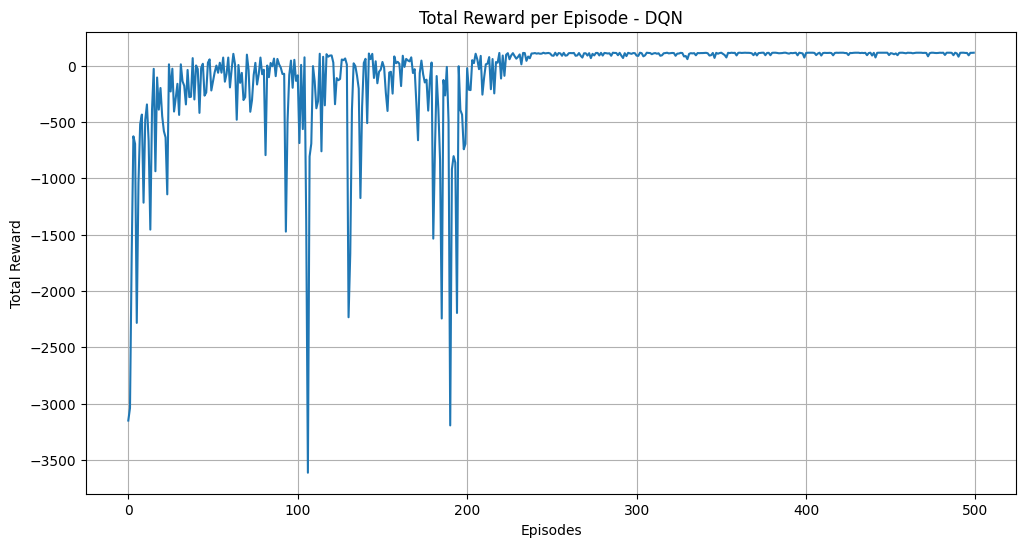

In [ ]:
plt.figure(figsize=(12, 6))#plotting reward per episodes DQN
plt.plot(rewards)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Total Reward per Episode - DQN")
plt.grid()
plt.show()


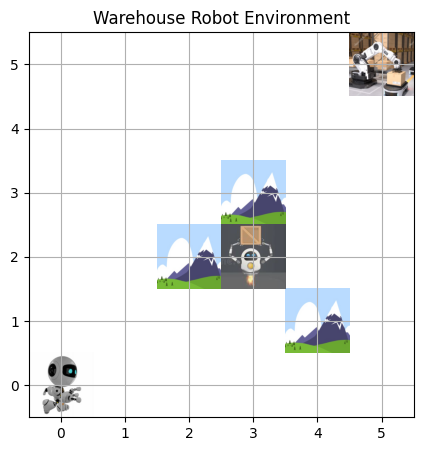

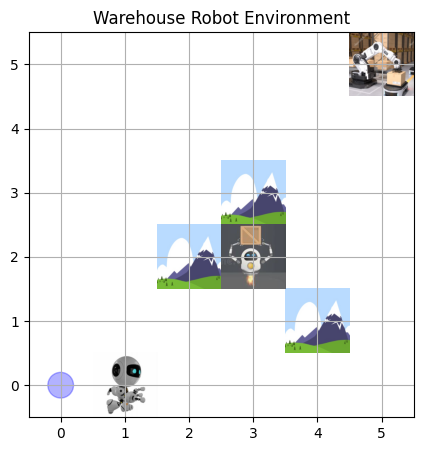

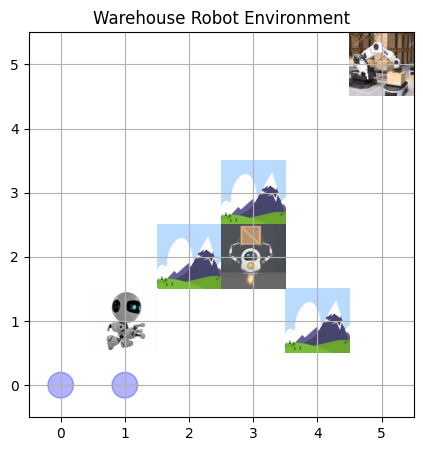

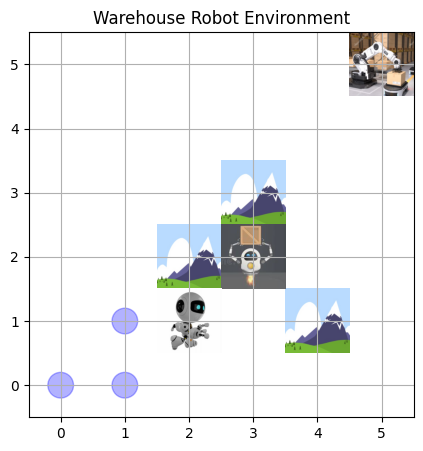

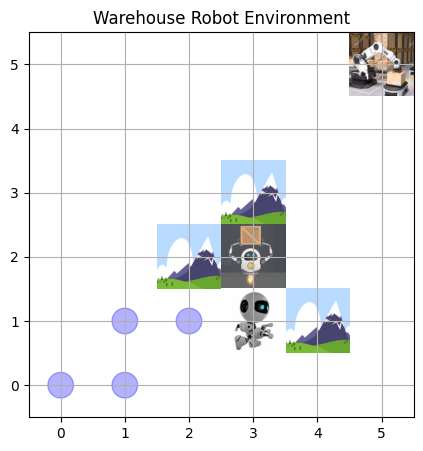

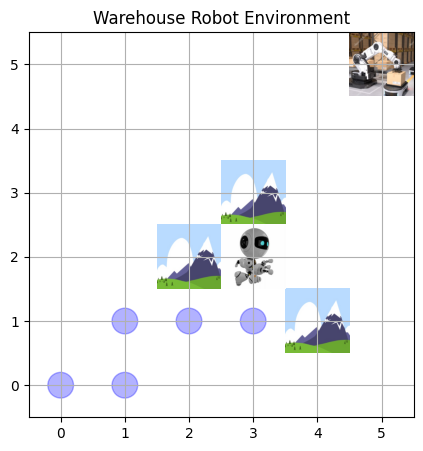

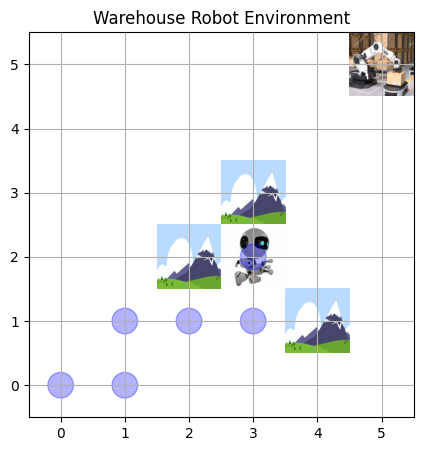

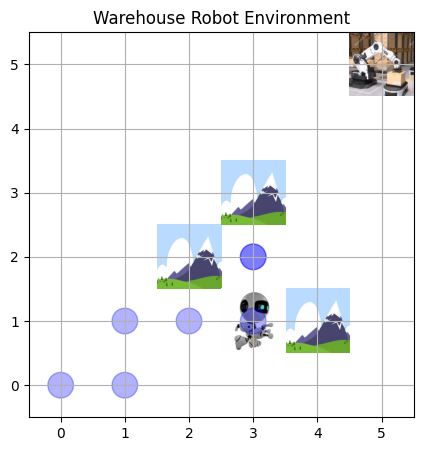

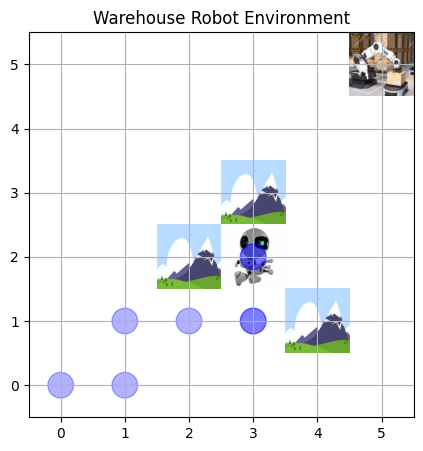

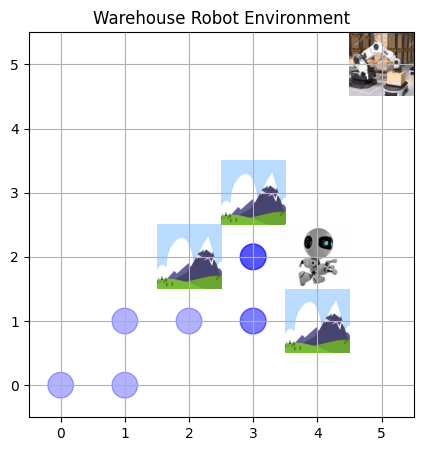

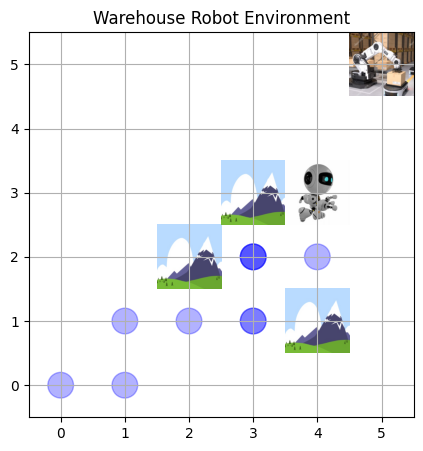

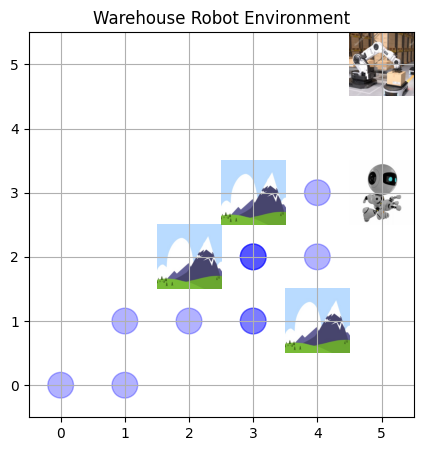

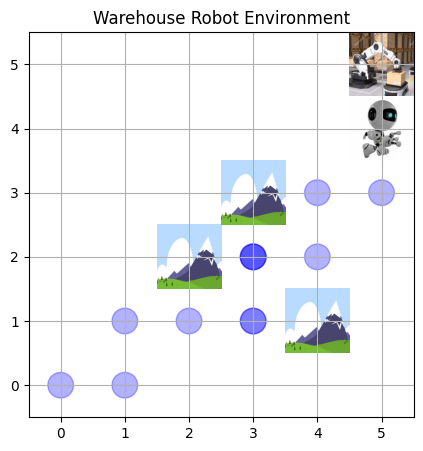

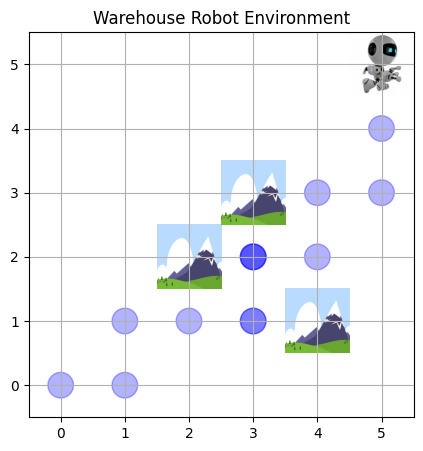

In [ ]:
state, _ = env.reset()
state = agent._flatten_state(state)
done = False
while not done:
    env.render()
    action = agent.select_action(state)
    next_state, reward, done, _, _ = env.step(action)
    state = agent._flatten_state(next_state)


Model weights loaded.
Episode 1, Total Reward: 115
Episode 2, Total Reward: 115
Episode 3, Total Reward: 115
Episode 4, Total Reward: 115
Episode 5, Total Reward: 115


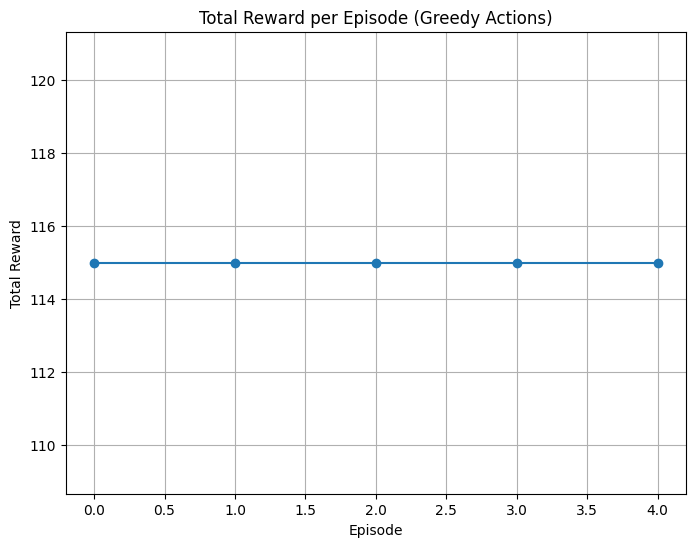

In [ ]:
# Loading pretrained weights
agent.policy_net.load_state_dict(torch.load("dqn_WarehouseRobot_weights.pth"))
agent.policy_net.eval()  #evaluation mode
print("Model weights loaded.")

# Run 5 episodes with greedy actions
total_rewards = []
for episode in range(5):
    state, _ = env.reset()
    state = agent._flatten_state(state)
    total_reward = 0
    done = False
    while not done:
        # Select action greedily
        with torch.no_grad():
            action = agent.policy_net(torch.tensor([state], dtype=torch.float32)).argmax().item()
        next_state, reward, done, _, _ = env.step(action)
        next_state = agent._flatten_state(next_state)
        state = next_state
        total_reward += reward
    total_rewards.append(total_reward)
    print(f"Episode {episode + 1}, Total Reward: {total_reward}")

#total rewards per episode
plt.figure(figsize=(8, 6))
plt.plot(total_rewards, marker='o')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Total Reward per Episode (Greedy Actions)")
plt.grid(True)
plt.show()

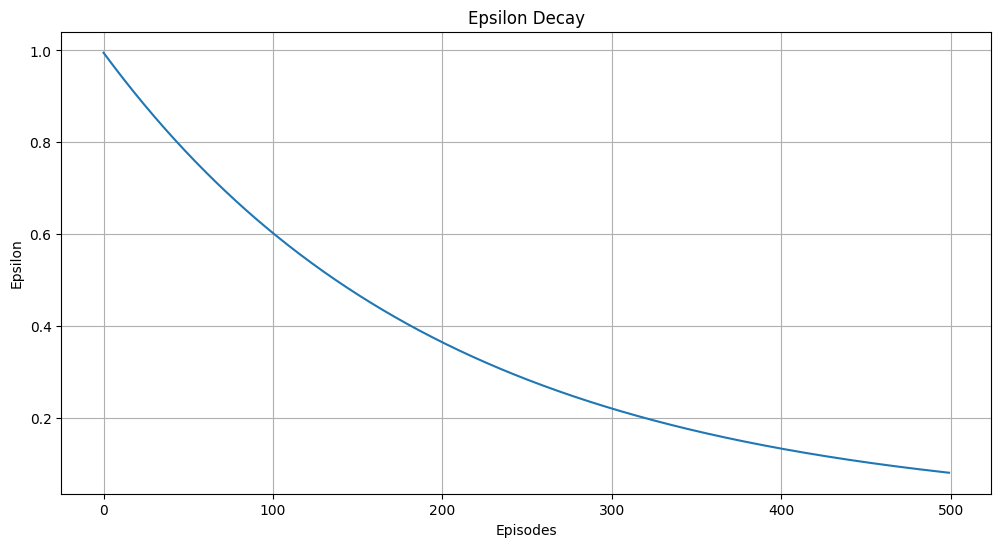

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(epsilons)
plt.xlabel("Episodes")
plt.ylabel("Epsilon")
plt.title("Epsilon Decay")
plt.grid()
plt.show()

Episode 0, Reward: 12.0, Epsilon: 0.995
Episode 1, Reward: 28.0, Epsilon: 0.990
Episode 2, Reward: 10.0, Epsilon: 0.985
Episode 3, Reward: 45.0, Epsilon: 0.980
Episode 4, Reward: 15.0, Epsilon: 0.975
Episode 5, Reward: 10.0, Epsilon: 0.970
Episode 6, Reward: 11.0, Epsilon: 0.966
Episode 7, Reward: 20.0, Epsilon: 0.961
Episode 8, Reward: 25.0, Epsilon: 0.956
Episode 9, Reward: 63.0, Epsilon: 0.951
Episode 10, Reward: 12.0, Epsilon: 0.946
Episode 11, Reward: 14.0, Epsilon: 0.942
Episode 12, Reward: 13.0, Epsilon: 0.937
Episode 13, Reward: 33.0, Epsilon: 0.932
Episode 14, Reward: 11.0, Epsilon: 0.928
Episode 15, Reward: 10.0, Epsilon: 0.923
Episode 16, Reward: 14.0, Epsilon: 0.918
Episode 17, Reward: 15.0, Epsilon: 0.914
Episode 18, Reward: 14.0, Epsilon: 0.909
Episode 19, Reward: 27.0, Epsilon: 0.905
Episode 20, Reward: 25.0, Epsilon: 0.900
Episode 21, Reward: 14.0, Epsilon: 0.896
Episode 22, Reward: 15.0, Epsilon: 0.891
Episode 23, Reward: 13.0, Epsilon: 0.887
Episode 24, Reward: 12.0, 

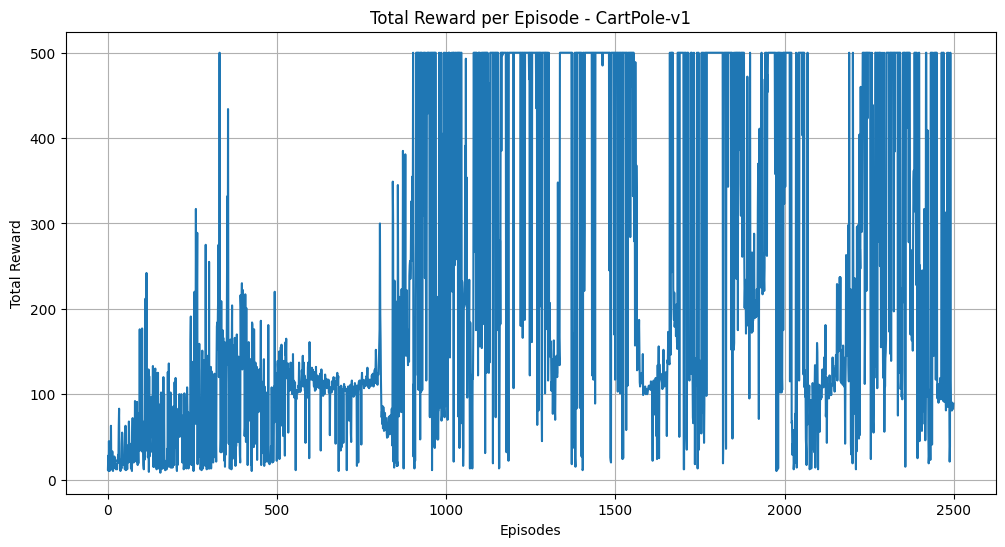

In [ ]:
#CartPole environment
cartpole_env = gym.make('CartPole-v1')
state_dim = cartpole_env.observation_space.shape[0]
action_dim = cartpole_env.action_space.n

# New-agent for CartPole
cartpole_agent = DQNAgent(cartpole_env, state_dim, action_dim)

# Flatten function for CartPole
cartpole_agent._flatten_state = lambda s: np.array(s, dtype=np.float32)

# Training
cartpole_rewards, cartpole_epsilons = cartpole_agent.train(episodes=2500)

# Plotting cartPole reward per episode
plt.figure(figsize=(12, 6))
plt.plot(cartpole_rewards)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Total Reward per Episode - CartPole-v1")
plt.grid()
plt.show()

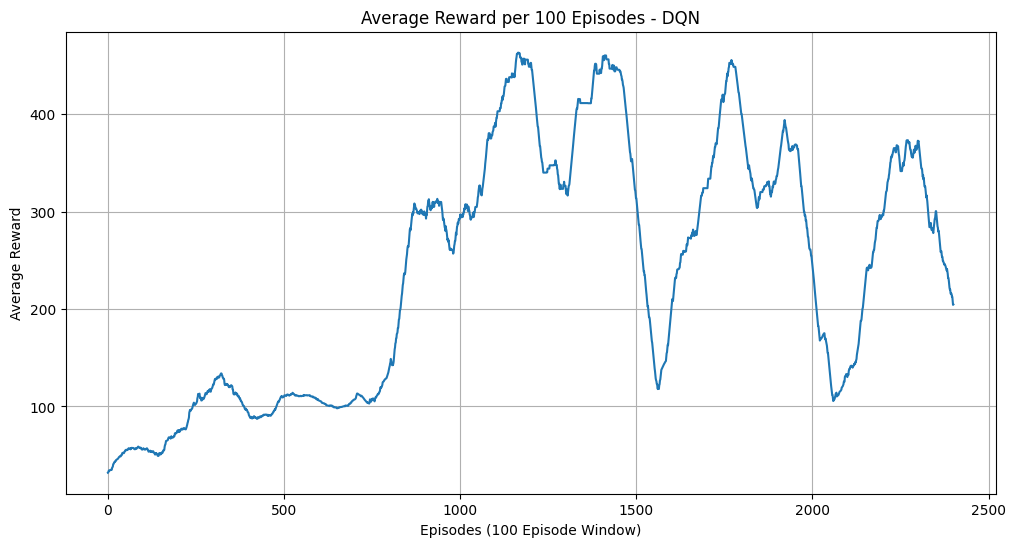

In [ ]:
def calculate_average_reward(rewards, window=100):

  average_rewards = []
  for i in range(len(rewards) - window + 1):
    average_rewards.append(np.mean(rewards[i:i+window]))
  return average_rewards

# Example usage (assuming 'rewards' is your list of rewards):
average_rewards_100 = calculate_average_reward(cartpole_rewards, window=100)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(average_rewards_100)
plt.xlabel("Episodes (100 Episode Window)")
plt.ylabel("Average Reward")
plt.title("Average Reward per 100 Episodes - DQN")
plt.grid()
plt.show()


In [ ]:
cartpole_agent.train(episodes=750, save_best=True, save_path="best_dqn_CartPole-v1_weights.pth")


Episode 0, Reward: 76.0, Epsilon: 0.010
Episode 1, Reward: 25.0, Epsilon: 0.010
Episode 2, Reward: 500.0, Epsilon: 0.010
Episode 3, Reward: 500.0, Epsilon: 0.010
Episode 4, Reward: 500.0, Epsilon: 0.010
Episode 5, Reward: 500.0, Epsilon: 0.010
Episode 6, Reward: 500.0, Epsilon: 0.010
Episode 7, Reward: 500.0, Epsilon: 0.010
Episode 8, Reward: 149.0, Epsilon: 0.010
Episode 9, Reward: 500.0, Epsilon: 0.010
Episode 10, Reward: 124.0, Epsilon: 0.010
Episode 11, Reward: 346.0, Epsilon: 0.010
Episode 12, Reward: 31.0, Epsilon: 0.010
Episode 13, Reward: 500.0, Epsilon: 0.010
Episode 14, Reward: 500.0, Epsilon: 0.010
Episode 15, Reward: 500.0, Epsilon: 0.010
Episode 16, Reward: 28.0, Epsilon: 0.010
Episode 17, Reward: 500.0, Epsilon: 0.010
Episode 18, Reward: 500.0, Epsilon: 0.010
Episode 19, Reward: 94.0, Epsilon: 0.010
Episode 20, Reward: 16.0, Epsilon: 0.010
Episode 21, Reward: 32.0, Epsilon: 0.010
Episode 22, Reward: 165.0, Epsilon: 0.010
Episode 23, Reward: 15.0, Epsilon: 0.010
Episode 24

([76.0,
  25.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  149.0,
  500.0,
  124.0,
  346.0,
  31.0,
  500.0,
  500.0,
  500.0,
  28.0,
  500.0,
  500.0,
  94.0,
  16.0,
  32.0,
  165.0,
  15.0,
  115.0,
  500.0,
  116.0,
  18.0,
  29.0,
  215.0,
  82.0,
  500.0,
  500.0,
  19.0,
  500.0,
  500.0,
  19.0,
  500.0,
  500.0,
  500.0,
  332.0,
  500.0,
  500.0,
  137.0,
  13.0,
  500.0,
  265.0,
  500.0,
  27.0,
  188.0,
  19.0,
  500.0,
  500.0,
  500.0,
  500.0,
  394.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  150.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  288.0,
  500.0,
  500.0,
  152.0,
  500.0,
  495.0,
  500.0,
  500.0,
  177.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  494.0,
  500.0,
  500.0,
  242.0,
  500.0,
  62.0,
  496.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  500.0,
  118.0,
  355.0,
  500.0,


In [ ]:
# Recreate CartPole env & agent (clean and isolated)
import gymnasium as gym
import torch

# Environment setup
cp_env = gym.make("CartPole-v1")
cp_state_dim = cp_env.observation_space.shape[0]   # 4
cp_action_dim = cp_env.action_space.n              # 2

# Reinitialize CartPole-specific agent
cp_agent = DQNAgent(
    env=cp_env,
    state_dim=cp_state_dim,
    action_dim=cp_action_dim
)

# Load the best CartPole model
cp_agent.policy_net.load_state_dict(torch.load("best_dqn_CartPole-v1_weights.pth"))
cp_agent.epsilon = 0.0  # Greedy only

# Greedy evaluation over 5 episodes
greedy_rewards = []
for i in range(5):
    state, _ = cp_env.reset()
    state = cp_agent._flatten_state(state)
    done = False
    total_reward = 0

    while not done:
        action = cp_agent.select_action(state)
        next_state, reward, terminated, truncated, _ = cp_env.step(action)
        done = terminated or truncated
        state = cp_agent._flatten_state(next_state)
        total_reward += reward

    greedy_rewards.append(total_reward)
    print(f"Greedy Eval Episode {i+1}: Reward = {total_reward}")

# Final average
avg_reward = sum(greedy_rewards) / len(greedy_rewards)
print(f" Average Greedy Reward: {avg_reward}")


Greedy Eval Episode 1: Reward = 500.0
Greedy Eval Episode 2: Reward = 500.0
Greedy Eval Episode 3: Reward = 500.0
Greedy Eval Episode 4: Reward = 500.0
Greedy Eval Episode 5: Reward = 500.0
 Average Greedy Reward: 500.0


Text(0.5, 1.0, 'Total Reward per Episode (Greedy Actions) - CartPole-v1')

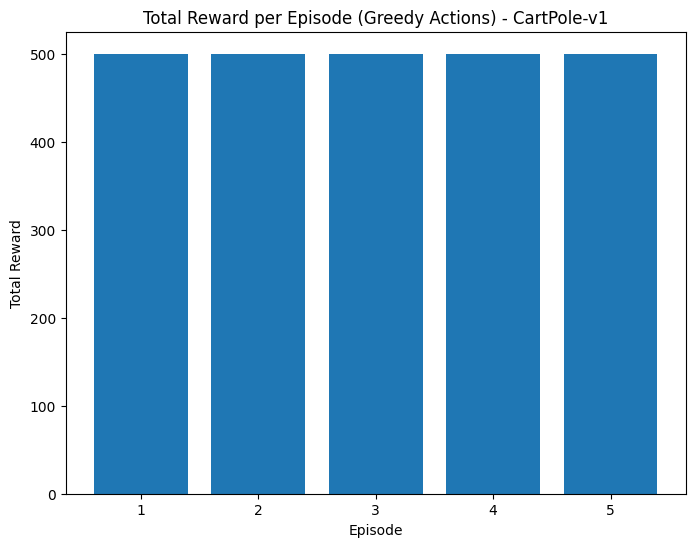

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.bar(range(1, 6), greedy_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Total Reward per Episode (Greedy Actions) - CartPole-v1")

In [ ]:
!apt-get install -y swig


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  swig4.0
Suggested packages:
  swig-doc swig-examples swig4.0-examples swig4.0-doc
The following NEW packages will be installed:
  swig swig4.0
0 upgraded, 2 newly installed, 0 to remove and 30 not upgraded.
Need to get 1,116 kB of archives.
After this operation, 5,542 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig4.0 amd64 4.0.2-1ubuntu1 [1,110 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig all 4.0.2-1ubuntu1 [5,632 B]
Fetched 1,116 kB in 1s (1,111 kB/s)
Selecting previously unselected package swig4.0.
(Reading database ... 126213 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb ...
Unpacking swig4.0 (4.0.2-1ubuntu1) ...
Selecting previously unselected package swig.
Preparing to unpack .../swig_4.0.2-1ubu

In [ ]:
!pip install "gymnasium[box2d]"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 45.0 MB/s eta 0:00:00
  Created wheel for box2d-py: filename=box2d_py-2.3.5-cp311-cp311-linux_x86_64.whl size=2351227 sha256=8cdbafdffdf8e6c3f9b19e3fcf285a2c56e70d8604e0f4ca5fa71b1c3e143023
  Stored in directory: /root/.cache/pip/wheels/ab/f1/0c/d56f4a2bdd12bae0a0693ec33f2f0daadb5eb9753c78fa5308
Successfully built box2d-py


Episode 0, Reward: -266.00, Epsilon: 0.990
Episode 1, Reward: -316.17, Epsilon: 0.980
Episode 2, Reward: -336.86, Epsilon: 0.970
Episode 3, Reward: -7.57, Epsilon: 0.961
Episode 4, Reward: -46.97, Epsilon: 0.951
Episode 5, Reward: -231.95, Epsilon: 0.942
Episode 6, Reward: -90.65, Epsilon: 0.932
Episode 7, Reward: -52.53, Epsilon: 0.923
Episode 8, Reward: -46.77, Epsilon: 0.914
Episode 9, Reward: -115.77, Epsilon: 0.905
Episode 10, Reward: -362.53, Epsilon: 0.896
Episode 11, Reward: -157.90, Epsilon: 0.887
Episode 12, Reward: -26.58, Epsilon: 0.878
Episode 13, Reward: -82.97, Epsilon: 0.869
Episode 14, Reward: -33.34, Epsilon: 0.860
Episode 15, Reward: -176.73, Epsilon: 0.852
Episode 16, Reward: -180.87, Epsilon: 0.843
Episode 17, Reward: -147.07, Epsilon: 0.835
Episode 18, Reward: -121.39, Epsilon: 0.827
Episode 19, Reward: -205.88, Epsilon: 0.818
Episode 20, Reward: -99.54, Epsilon: 0.810
Episode 21, Reward: -13.63, Epsilon: 0.802
Episode 22, Reward: -274.95, Epsilon: 0.794
Episode 2

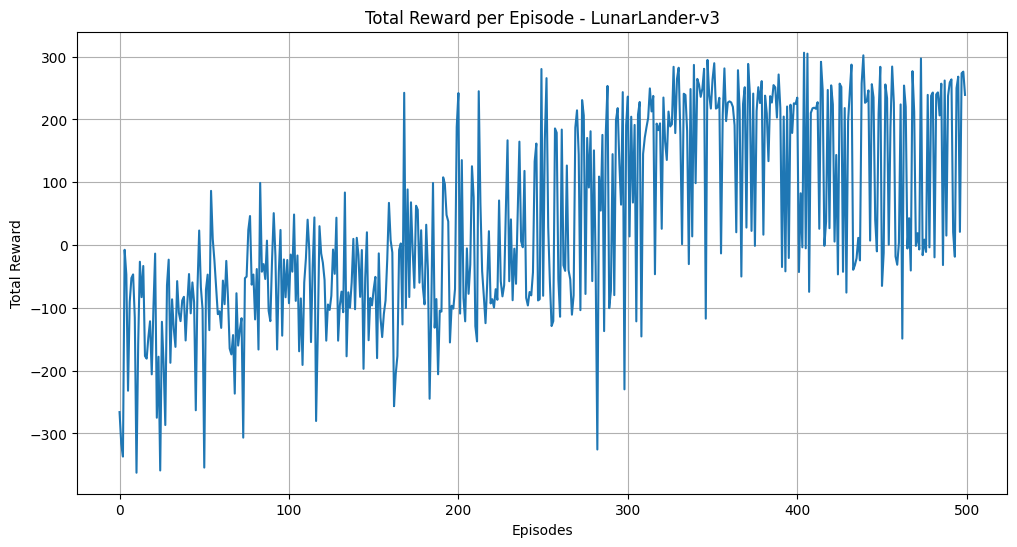

In [ ]:
# Initialize LunarLander-v3
lander_env20 = gym.make('LunarLander-v3')
state_dim = lander_env20.observation_space.shape[0]
action_dim = lander_env20.action_space.n

# new DQN agent
lander_agent20 = DQNAgent(lander_env20, state_dim, action_dim)
lander_agent20._flatten_state = lambda s: np.array(s, dtype=np.float32)

# train function with max_steps
def train_lander(agent, env, episodes=500, max_steps=1000):
    rewards_per_episode = []
    epsilons = []

    for episode in range(episodes):
        state, _ = env.reset()
        state = agent._flatten_state(state)
        total_reward = 0
        done = False
        steps = 0

        while not done and steps < max_steps:
            action = agent.select_action(state)
            next_state, reward, done, truncated, _ = env.step(action)
            next_state = agent._flatten_state(next_state)

            agent.memory.push(state, action, reward, next_state, done)
            state = next_state

            agent.train_step()
            total_reward += reward
            steps += 1
        agent.epsilon = max(agent.min_epsilon, agent.epsilon * agent.epsilon_decay)
        epsilons.append(agent.epsilon)
        if steps == max_steps:
            print(f"Episode {episode} truncated after {max_steps} steps.")

        agent.epsilon = max(agent.min_epsilon, agent.epsilon * agent.epsilon_decay)

        if episode % agent.target_update == 0:
            agent.target_net.load_state_dict(agent.policy_net.state_dict())

        rewards_per_episode.append(total_reward)
        print(f"Episode {episode}, Reward: {total_reward:.2f}, Epsilon: {agent.epsilon:.3f}")

    return rewards_per_episode, epsilons

# Train the agent
lander_rewards, lander_epsilons = train_lander(lander_agent20, lander_env20, episodes=500)

# Plotting reward dynamics
plt.figure(figsize=(12, 6))
plt.plot(lander_rewards)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Total Reward per Episode - LunarLander-v3")
plt.grid()
plt.show()


Episode 1, Reward: -22.46729883973488
Episode 2, Reward: 269.5499700222541
Episode 3, Reward: 258.5591450969786
Episode 4, Reward: 244.01386754087798
Episode 5, Reward: 274.11088844409676


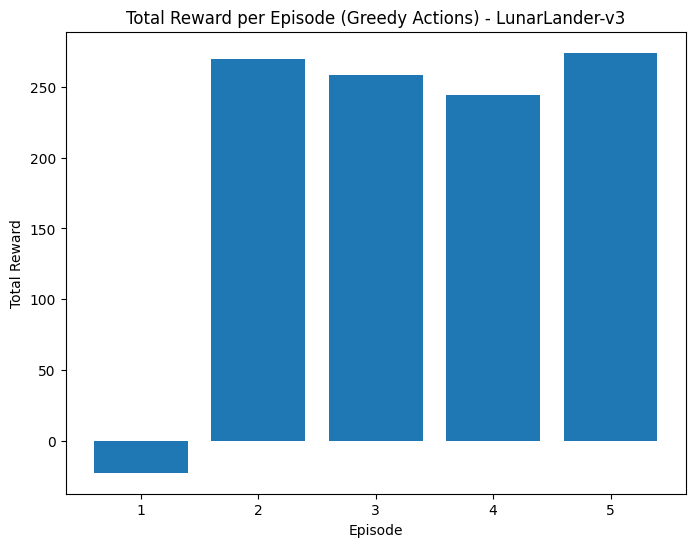

In [ ]:
lander_agent20.epsilon = 0.0  # epsilon = 0 for greedy actions
greedy_rewards2 = []
for episode in range(5):
    state, _ = lander_env20.reset()
    state = lander_agent20._flatten_state(state)
    done = False
    total_reward = 0
    while not done:
        action = lander_agent20.select_action(state)
        next_state, reward, done, _, _ = lander_env20.step(action)
        state = lander_agent20._flatten_state(next_state)
        total_reward += reward
    greedy_rewards2.append(total_reward)
    print(f"Episode {episode+1}, Reward: {total_reward}")

plt.figure(figsize=(8, 6))
plt.bar(range(1, 6), greedy_rewards2)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Total Reward per Episode (Greedy Actions) - LunarLander-v3")
plt.show()

In [ ]:
def plot_training_results(rewards, epsilons, title_prefix):
    fig, axs = plt.subplots(2, 1, figsize=(12, 10))

    axs[0].plot(rewards)
    axs[0].set_title(f"{title_prefix} - Total Reward per Episode")
    axs[0].set_xlabel("Episode")
    axs[0].set_ylabel("Total Reward")
    axs[0].grid()

    axs[1].plot(epsilons)
    axs[1].set_title(f"{title_prefix} - Epsilon Decay")
    axs[1].set_xlabel("Episode")
    axs[1].set_ylabel("Epsilon")
    axs[1].grid()

    plt.tight_layout()
    plt.show()

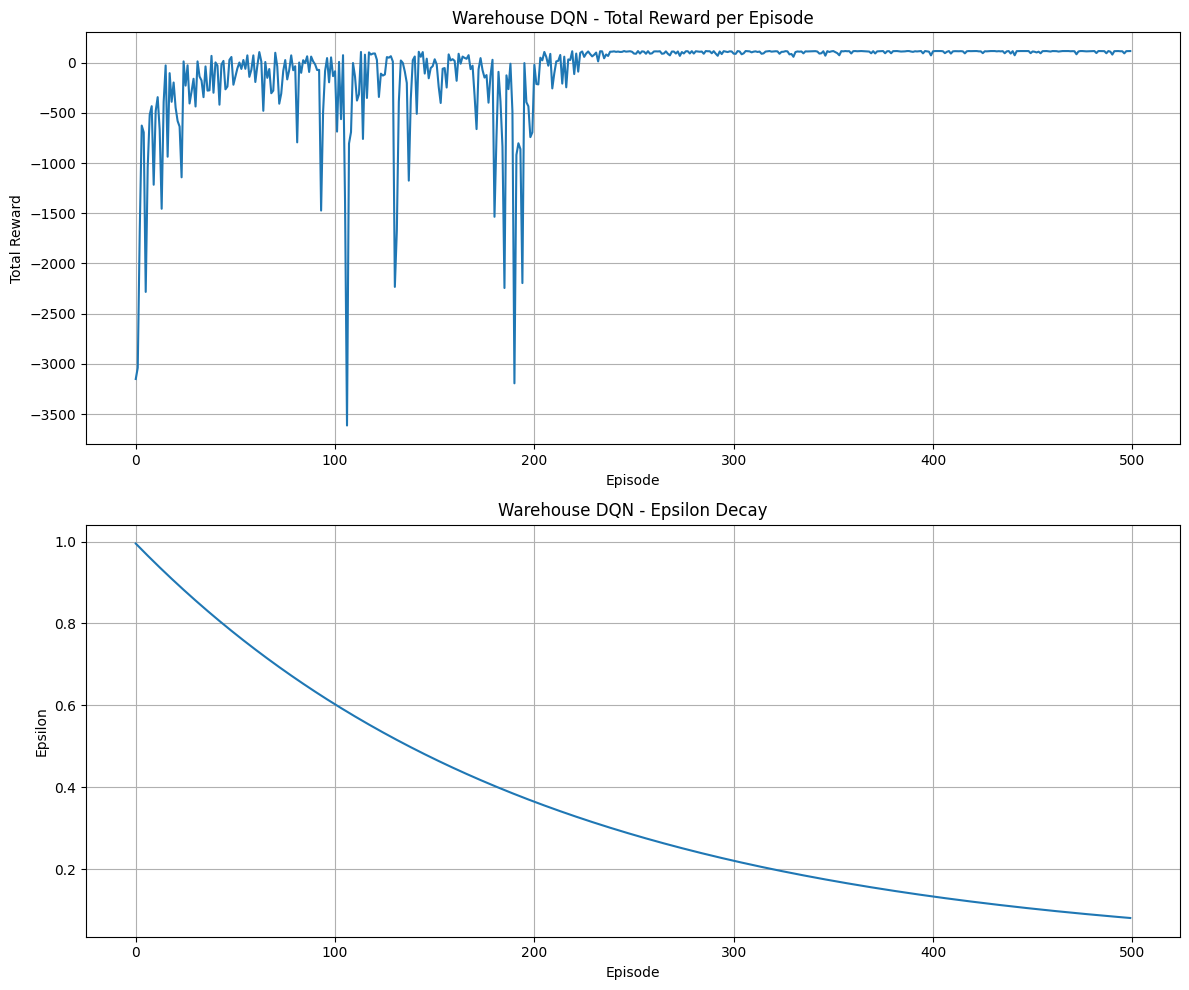

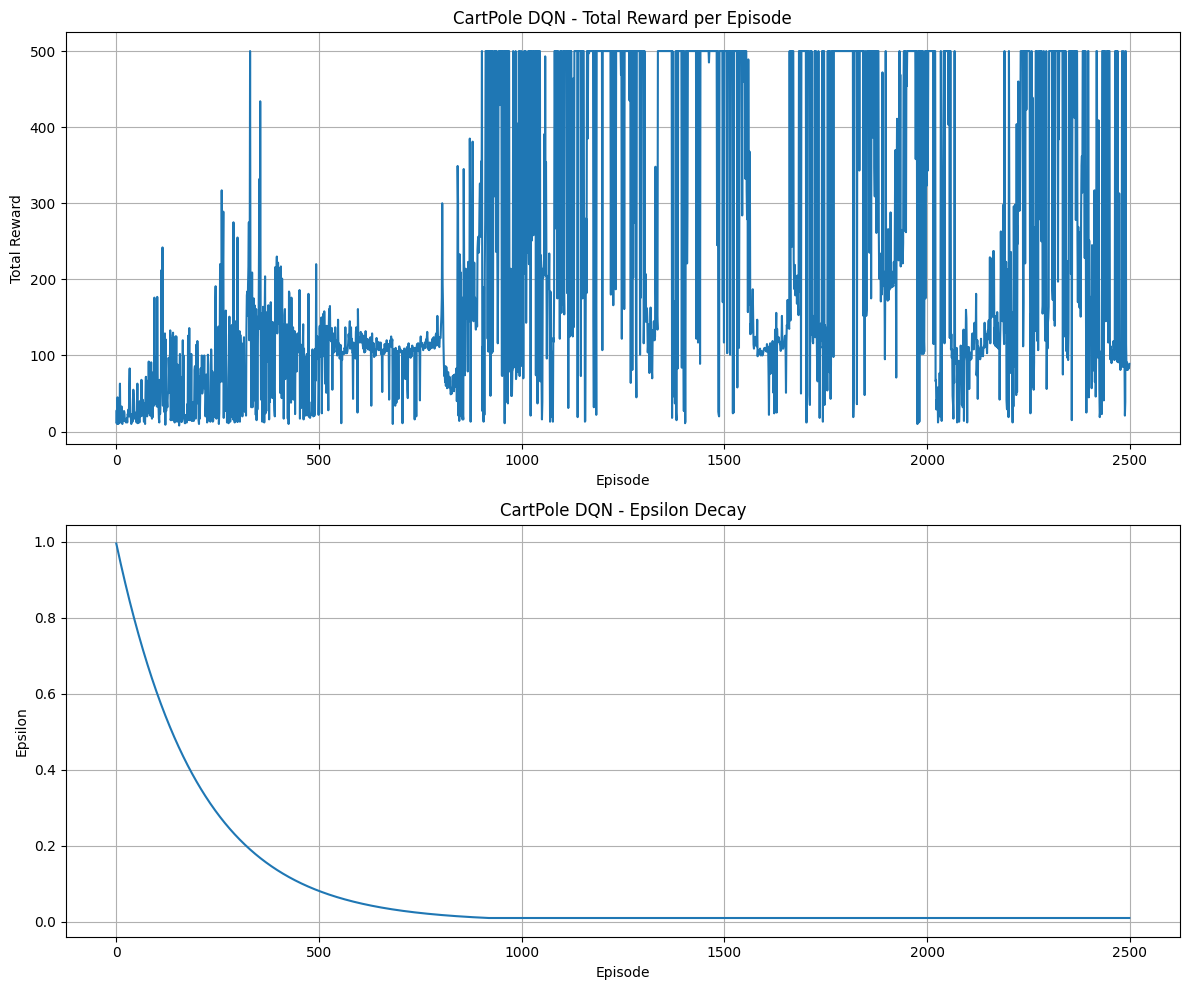

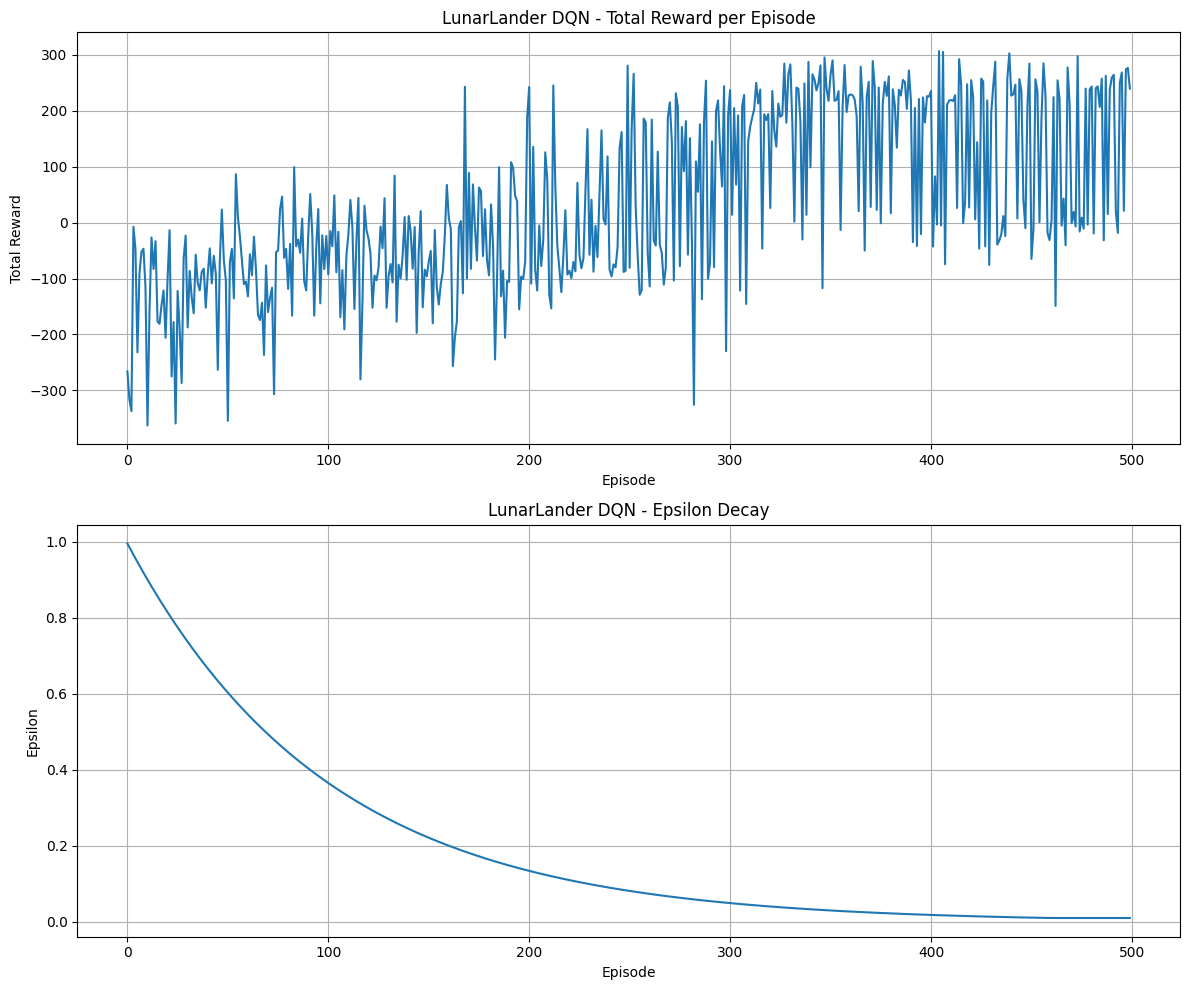

In [ ]:
plot_training_results(rewards, epsilons, "Warehouse DQN")
plot_training_results(cartpole_rewards, cartpole_epsilons, "CartPole DQN")
plot_training_results(lander_rewards, lander_epsilons, "LunarLander DQN")


In [ ]:
# Save LunarLander model weights
torch.save(lander_agent20.policy_net.state_dict(), "dqn_LunarLander_weights.pth")


**DDQN CODES**

In [ ]:
class DDQNAgent:
    def __init__(self, env, state_dim, action_dim, buffer_size=10000, batch_size=64,
                 gamma=0.99, lr=1e-3, epsilon=1.0, epsilon_decay=0.995,
                 min_epsilon=0.01, target_update=50):

        self.env = env
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.batch_size = batch_size
        self.gamma = gamma
        self.lr = lr
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.target_update = target_update

        self.policy_net = DQN(state_dim, action_dim)
        self.target_net = DQN(state_dim, action_dim)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(buffer_size)
        self.steps_done = 0
    def select_action(self, state):
        if random.random() < self.epsilon:
            return self.env.action_space.sample()
        state = torch.tensor([state], dtype=torch.float32)
        with torch.no_grad():
            return self.policy_net(state).argmax().item()

    def ddqn_train_step(self):
        if len(self.memory) < self.batch_size:
            return

        state, action, reward, next_state, done = self.memory.sample(self.batch_size)

        state = torch.tensor(state, dtype=torch.float32)
        action = torch.tensor(action, dtype=torch.int64).unsqueeze(1)
        reward = torch.tensor(reward, dtype=torch.float32).unsqueeze(1)
        next_state = torch.tensor(next_state, dtype=torch.float32)
        done = torch.tensor(done, dtype=torch.float32).unsqueeze(1)

        next_actions = self.policy_net(next_state).argmax(1).unsqueeze(1)
        next_q_values = self.target_net(next_state).gather(1, next_actions)

        expected_q = reward + (1 - done) * self.gamma * next_q_values

        q_values = self.policy_net(state).gather(1, action)
        loss = nn.functional.mse_loss(q_values, expected_q)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

    def train(self, episodes, save_best=False, save_path="best_ddqn_model.pth"):
        rewards_per_episode = []
        epsilons = []
        steps = 0
        best_reward = -float("inf") if save_best else None

        for episode in range(episodes):
            state, _ = self.env.reset()
            state = self._flatten_state(state)
            total_reward = 0
            done = False

            while not done:
                action = self.select_action(state)
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated
                next_state = self._flatten_state(next_state)

                self.memory.push(state, action, reward, next_state, done)
                state = next_state

                self.ddqn_train_step()
                total_reward += reward
            self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)
            epsilons.append(self.epsilon)
            rewards_per_episode.append(total_reward)

            if save_best and total_reward > best_reward:
                best_reward = total_reward
                torch.save(self.policy_net.state_dict(), save_path)

            if episode % self.target_update == 0:
                self.target_net.load_state_dict(self.policy_net.state_dict())

            print(f"[DDQN] Episode {episode}, Reward: {total_reward}, Epsilon: {self.epsilon:.3f}")

        env_name = getattr(self.env, "spec", None)
        env_id = env_name.id if env_name is not None else "WarehouseRobot"
        torch.save(self.policy_net.state_dict(), f"ddqn_{env_id}_weights.pth")

        return rewards_per_episode, epsilons

    def _flatten_state(self, state):
        return np.array(state, dtype=np.float32)


In [ ]:
import gym
from gym import spaces
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import random

class WarehouseDDQNEnv(gym.Env):
    def __init__(self, stochastic=False):
        super(WarehouseDDQNEnv, self).__init__()

        self.grid_size = 6  # 6x6 Grid
        self.obstacles = [(2, 2), (3, 3), (4, 1)]
        self.pickup_location = (3, 2)
        self.dropoff_location = (5, 5)
        self.robot_position = (0, 0)
        self.has_item = False
        self.stochastic = stochastic
        self.visited_positions = []

        # Images
        self.robot_img = mpimg.imread("agent.jpg")
        self.pickup_img = mpimg.imread("pickup.jpg")
        self.dropoff_img = mpimg.imread("dropoff.jpg")
        self.obstacle_img = mpimg.imread("obstacles.jpg")

        # Action space
        self.action_space = spaces.Discrete(6)

        self.observation_space = spaces.Box(low=0, high=1, shape=(3,), dtype=np.float32)

    def step(self, action):
        x, y = self.robot_position
        reward = -1
        terminated = False
        truncated = False
        info = {}

        if action == 0:
            new_position = (x, y - 1)
        elif action == 1:
            new_position = (x, y + 1)
        elif action == 2:
            new_position = (x - 1, y)
        elif action == 3:
            new_position = (x + 1, y)
        elif action == 4 and self.robot_position == self.pickup_location and not self.has_item:
            self.has_item = True
            reward = 25
            new_position = self.robot_position
        elif action == 5 and self.robot_position == self.dropoff_location and self.has_item:
            reward = 100
            terminated = True
            new_position = self.robot_position
        else:
            new_position = self.robot_position

        # Boundary checks
        if not (0 <= new_position[0] < self.grid_size and 0 <= new_position[1] < self.grid_size):
            new_position = self.robot_position

        if new_position in self.obstacles:
            reward -= 20
            new_position = self.robot_position

        if self.stochastic and random.random() < 0.1:
            new_position = self.robot_position

        self.visited_positions.append(self.robot_position)
        self.robot_position = new_position
        observation = (*self.robot_position, int(self.has_item))

        return np.array(observation, dtype=np.float32), reward, terminated, truncated, info

    def reset(self):
        self.robot_position = (0, 0)
        self.has_item = False
        self.visited_positions.clear()
        observation = (*self.robot_position, int(self.has_item))
        info = {}
        return np.array(observation, dtype=np.float32), info

    def render(self):
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.set_xlim(-0.5, self.grid_size - 0.5)
        ax.set_ylim(-0.5, self.grid_size - 0.5)

        for ox, oy in self.obstacles:
            ax.imshow(self.obstacle_img, extent=[ox - 0.5, ox + 0.5, oy - 0.5, oy + 0.5])

        if not self.has_item:
            ax.imshow(self.pickup_img, extent=[self.pickup_location[0] - 0.5, self.pickup_location[0] + 0.5,
                                               self.pickup_location[1] - 0.5, self.pickup_location[1] + 0.5])

        ax.imshow(self.dropoff_img, extent=[self.dropoff_location[0] - 0.5, self.dropoff_location[0] + 0.5,
                                            self.dropoff_location[1] - 0.5, self.dropoff_location[1] + 0.5])

        ax.imshow(self.robot_img, extent=[self.robot_position[0] - 0.5, self.robot_position[0] + 0.5,
                                          self.robot_position[1] - 0.5, self.robot_position[1] + 0.5])

        for pos in self.visited_positions:
            ax.add_patch(plt.Circle((pos[0], pos[1]), 0.2, color='blue', alpha=0.3))

        plt.grid(True)
        plt.title("Warehouse Robot Environment (Double DQN)")
        plt.show()


In [ ]:
ddqn_grid_agent = DDQNAgent(
    env=gw_env,
    state_dim=gw_state_dim,
    action_dim=gw_action_dim,
    epsilon_decay=0.997,       # slower decay
    min_epsilon=0.05,
    target_update=50
)

ddqn_grid_rewards, ddqn_grid_eps = ddqn_grid_agent.train(
    episodes=750,
    save_best=True,
    save_path="best_ddqn_warehouse_weights.pth"
)


[DDQN] Episode 0, Reward: -1314, Epsilon: 0.997
[DDQN] Episode 1, Reward: -437, Epsilon: 0.994
[DDQN] Episode 2, Reward: -4505, Epsilon: 0.991
[DDQN] Episode 3, Reward: -1949, Epsilon: 0.988
[DDQN] Episode 4, Reward: -1153, Epsilon: 0.985
[DDQN] Episode 5, Reward: -1497, Epsilon: 0.982
[DDQN] Episode 6, Reward: -2020, Epsilon: 0.979
[DDQN] Episode 7, Reward: -2276, Epsilon: 0.976
[DDQN] Episode 8, Reward: -502, Epsilon: 0.973
[DDQN] Episode 9, Reward: -2718, Epsilon: 0.970
[DDQN] Episode 10, Reward: -516, Epsilon: 0.967
[DDQN] Episode 11, Reward: -3050, Epsilon: 0.965
[DDQN] Episode 12, Reward: -3860, Epsilon: 0.962
[DDQN] Episode 13, Reward: -1169, Epsilon: 0.959
[DDQN] Episode 14, Reward: -778, Epsilon: 0.956
[DDQN] Episode 15, Reward: -463, Epsilon: 0.953
[DDQN] Episode 16, Reward: -1786, Epsilon: 0.950
[DDQN] Episode 17, Reward: -1600, Epsilon: 0.947
[DDQN] Episode 18, Reward: -623, Epsilon: 0.945
[DDQN] Episode 19, Reward: -1641, Epsilon: 0.942
[DDQN] Episode 20, Reward: -1911, Ep

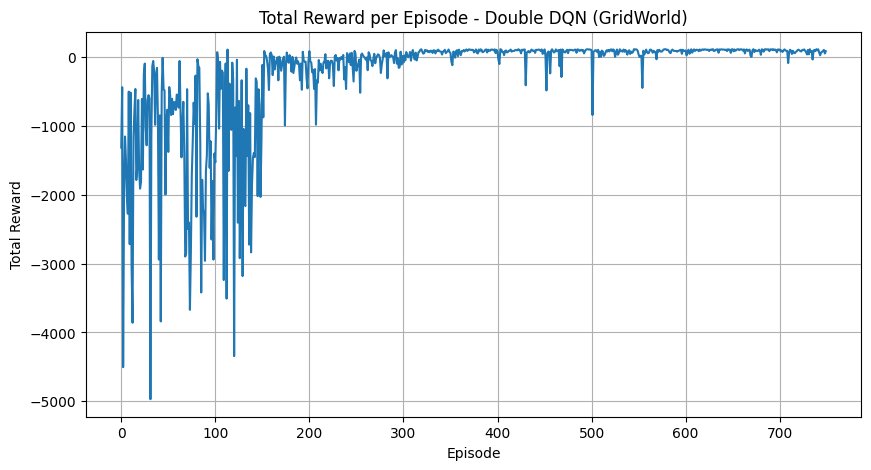

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(ddqn_grid_rewards)
plt.title("Total Reward per Episode - Double DQN (GridWorld)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()


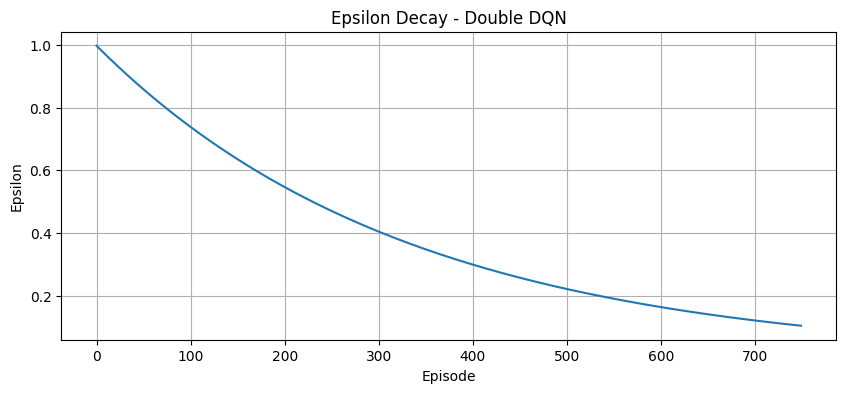

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(ddqn_grid_eps)
plt.title("Epsilon Decay - Double DQN")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.grid(True)
plt.show()


In [ ]:
ddqn_grid_agent.policy_net.load_state_dict(torch.load("best_ddqn_warehouse_weights.pth"))

ddqn_grid_agent.epsilon = 0.0


In [ ]:
# Evaluate 5 greedy episodes
grid_greedy_rewards = []

for ep in range(5):
    g_state, _ = gw_env.reset()
    g_state = ddqn_grid_agent._flatten_state(g_state)
    g_total_reward = 0
    g_done = False
    g_steps = 0
    g_max_steps = 200

    while not g_done and g_steps < g_max_steps:
        g_action = ddqn_grid_agent.select_action(g_state)
        g_next_state, g_reward, g_terminated, g_truncated, _ = gw_env.step(g_action)
        g_done = g_terminated or g_truncated
        g_state = ddqn_grid_agent._flatten_state(g_next_state)
        g_total_reward += g_reward
        g_steps += 1

    grid_greedy_rewards.append(g_total_reward)
    print(f"[Greedy] Episode {ep+1}, Reward: {g_total_reward}")


[Greedy] Episode 1, Reward: 102
[Greedy] Episode 2, Reward: 59
[Greedy] Episode 3, Reward: 83
[Greedy] Episode 4, Reward: 81
[Greedy] Episode 5, Reward: 111


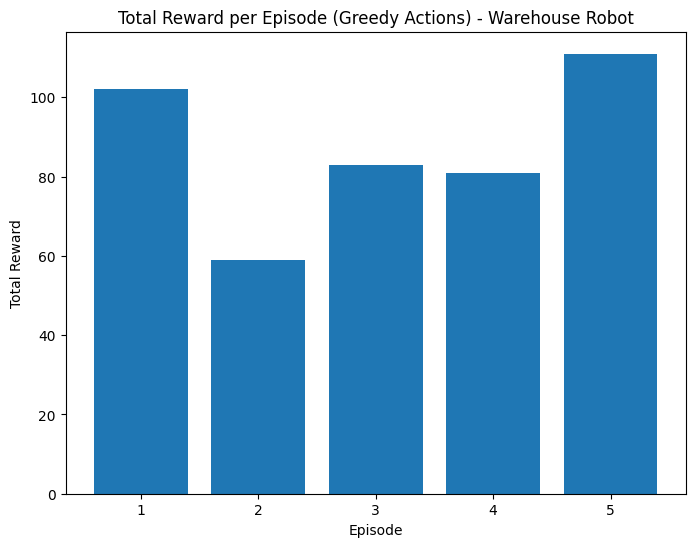

In [30]:
x_label = [1,2,3,4,5]
y_label = [102, 59, 83, 81,111]
plt.figure(figsize=(8, 6))
plt.bar(x_label, y_label)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Total Reward per Episode (Greedy Actions) - Warehouse Robot")
plt.show()

In [27]:
from collections import deque
import random
import numpy as np

class CartPoleReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        state = np.asarray(state, dtype=np.float32).flatten()
        next_state = np.asarray(next_state, dtype=np.float32).flatten()
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            np.stack(states),
            np.array(actions),
            np.array(rewards),
            np.stack(next_states),
            np.array(dones)
        )

    def __len__(self):
        return len(self.buffer)


In [28]:
class DDQNCartPoleAgent:
    def __init__(self, env, state_dim, action_dim, buffer_size=10000, batch_size=64,
                 gamma=0.99, lr=1e-3, epsilon=1.0, epsilon_decay=0.995,
                 min_epsilon=0.01, target_update=50):

        self.env = env
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.batch_size = batch_size
        self.gamma = gamma
        self.lr = lr
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.target_update = target_update

        self.policy_net = DQN(state_dim, action_dim)
        self.target_net = DQN(state_dim, action_dim)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = CartPoleReplayBuffer(buffer_size)
        self.steps_done = 0

    def select_action(self, state):
        if random.random() < self.epsilon:
            return self.env.action_space.sample()
        state = torch.tensor([state], dtype=torch.float32)
        with torch.no_grad():
            return self.policy_net(state).argmax().item()

    def cp_train_step(self):
        if len(self.memory) < self.batch_size:
            return

        state, action, reward, next_state, done = self.memory.sample(self.batch_size)

        state = torch.tensor(state, dtype=torch.float32)
        action = torch.tensor(action, dtype=torch.int64).unsqueeze(1)
        reward = torch.tensor(reward, dtype=torch.float32).unsqueeze(1)
        next_state = torch.tensor(next_state, dtype=torch.float32)
        done = torch.tensor(done.astype(np.float32)).unsqueeze(1)

        next_actions = self.policy_net(next_state).argmax(1).unsqueeze(1)
        next_q_values = self.target_net(next_state).gather(1, next_actions)

        expected_q = reward + (1 - done) * self.gamma * next_q_values

        q_values = self.policy_net(state).gather(1, action)
        loss = nn.functional.mse_loss(q_values, expected_q)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

    def train(self, episodes, save_best=False, save_path="best_ddqn_cartpole_weights.pth"):
        rewards_per_episode = []
        epsilons = []
        best_reward = -float("inf") if save_best else None

        for episode in range(episodes):
            state, _ = self.env.reset()
            total_reward = 0
            done = False

            while not done:
                action = self.select_action(state)
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated

                self.memory.push(state, action, reward, next_state, done)
                state = next_state

                self.cp_train_step()
                total_reward += reward

            self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)
            epsilons.append(self.epsilon)
            rewards_per_episode.append(total_reward)

            if save_best and total_reward > best_reward:
                best_reward = total_reward
                torch.save(self.policy_net.state_dict(), save_path)

            if episode % self.target_update == 0:
                self.target_net.load_state_dict(self.policy_net.state_dict())

            print(f"[DDQN-CP] Episode {episode}, Reward: {total_reward}, Epsilon: {self.epsilon:.3f}")

        torch.save(self.policy_net.state_dict(), save_path)
        return rewards_per_episode, epsilons

In [10]:
cp_env = gym.make("CartPole-v1")
cp_agent = DDQNCartPoleAgent(
    env=cp_env,
    state_dim=cp_env.observation_space.shape[0],
    action_dim=cp_env.action_space.n,
    epsilon_decay=0.995,
    min_epsilon=0.01,
    target_update=10
)

ddqn_cp_rewards, ddqn_cp_epsilons = cp_agent.train(
    episodes=1500,
    save_best=True,
    save_path="best_ddqn_cartpole_weights.pth"
)
#reward = torch.tensor(reward, dtype=torch.float32).unsqueeze(1)
#next_state = torch.tensor(next_state, dtype=torch.float32)
#done = torch.tensor(done.astype(np.float32)).unsqueeze(1)

[DDQN-CP] Episode 0, Reward: 65.0, Epsilon: 0.995
[DDQN-CP] Episode 1, Reward: 12.0, Epsilon: 0.990
[DDQN-CP] Episode 2, Reward: 12.0, Epsilon: 0.985
[DDQN-CP] Episode 3, Reward: 27.0, Epsilon: 0.980
[DDQN-CP] Episode 4, Reward: 24.0, Epsilon: 0.975
[DDQN-CP] Episode 5, Reward: 20.0, Epsilon: 0.970
[DDQN-CP] Episode 6, Reward: 16.0, Epsilon: 0.966
[DDQN-CP] Episode 7, Reward: 34.0, Epsilon: 0.961


<ipython-input-9-93007fa00cdf>:29: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  state = torch.tensor([state], dtype=torch.float32)


[DDQN-CP] Episode 8, Reward: 23.0, Epsilon: 0.956
[DDQN-CP] Episode 9, Reward: 13.0, Epsilon: 0.951
[DDQN-CP] Episode 10, Reward: 27.0, Epsilon: 0.946
[DDQN-CP] Episode 11, Reward: 10.0, Epsilon: 0.942
[DDQN-CP] Episode 12, Reward: 14.0, Epsilon: 0.937
[DDQN-CP] Episode 13, Reward: 12.0, Epsilon: 0.932
[DDQN-CP] Episode 14, Reward: 18.0, Epsilon: 0.928
[DDQN-CP] Episode 15, Reward: 16.0, Epsilon: 0.923
[DDQN-CP] Episode 16, Reward: 14.0, Epsilon: 0.918
[DDQN-CP] Episode 17, Reward: 19.0, Epsilon: 0.914
[DDQN-CP] Episode 18, Reward: 34.0, Epsilon: 0.909
[DDQN-CP] Episode 19, Reward: 17.0, Epsilon: 0.905
[DDQN-CP] Episode 20, Reward: 16.0, Epsilon: 0.900
[DDQN-CP] Episode 21, Reward: 11.0, Epsilon: 0.896
[DDQN-CP] Episode 22, Reward: 19.0, Epsilon: 0.891
[DDQN-CP] Episode 23, Reward: 13.0, Epsilon: 0.887
[DDQN-CP] Episode 24, Reward: 13.0, Epsilon: 0.882
[DDQN-CP] Episode 25, Reward: 43.0, Epsilon: 0.878
[DDQN-CP] Episode 26, Reward: 12.0, Epsilon: 0.873
[DDQN-CP] Episode 27, Reward: 31.

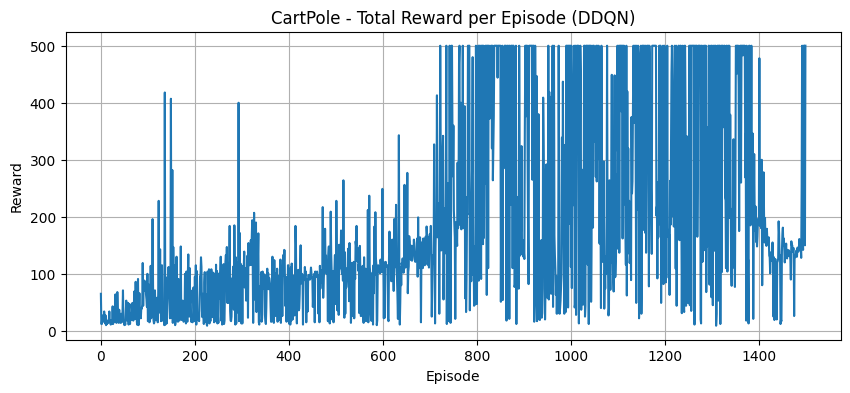

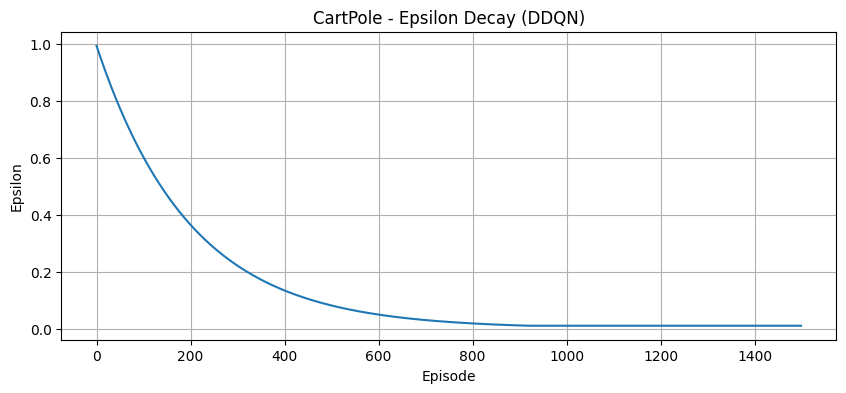

In [11]:
import matplotlib.pyplot as plt

# Plot total reward per episode
plt.figure(figsize=(10, 4))
plt.plot(ddqn_cp_rewards)
plt.title("CartPole - Total Reward per Episode (DDQN)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid()
plt.show()

# Plot epsilon decay
plt.figure(figsize=(10, 4))
plt.plot(ddqn_cp_epsilons)
plt.title("CartPole - Epsilon Decay (DDQN)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.grid()
plt.show()


In [17]:
cp_greedy_rewards = []

for ep in range(5):
    cp_state, _ = cp_env.reset()
    total_reward = 0
    done = False

    while not done:
        cp_action = cp_agent.select_action(cp_state)
        cp_next_state, cp_reward, cp_terminated, cp_truncated, _ = cp_env.step(cp_action)
        done = cp_terminated or cp_truncated
        cp_state = cp_next_state
        total_reward += cp_reward

    cp_greedy_rewards.append(total_reward)
    print(f"[DDQN-CP Greedy] Episode {ep+1}, Reward: {total_reward}")

[DDQN-CP Greedy] Episode 1, Reward: 500.0
[DDQN-CP Greedy] Episode 2, Reward: 500.0
[DDQN-CP Greedy] Episode 3, Reward: 500.0
[DDQN-CP Greedy] Episode 4, Reward: 500.0
[DDQN-CP Greedy] Episode 5, Reward: 500.0


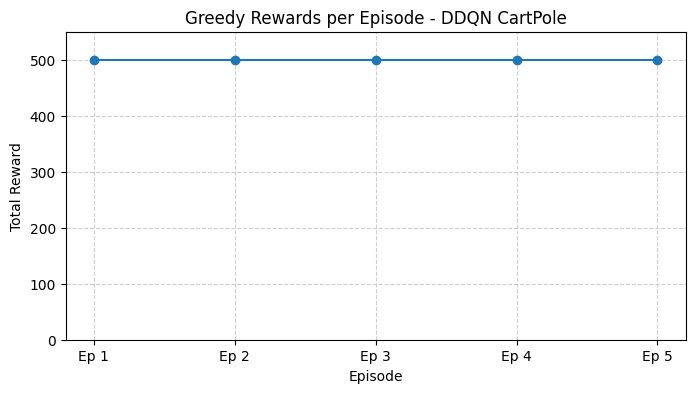

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(cp_greedy_rewards, marker='o')
plt.title("Greedy Rewards per Episode - DDQN CartPole")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.xticks(range(5), [f"Ep {i+1}" for i in range(5)])
plt.grid(True, linestyle="--", alpha=0.6)
plt.ylim(0, 550)
plt.show()


In [19]:
import numpy as np

def moving_average(data, window_size=100):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')


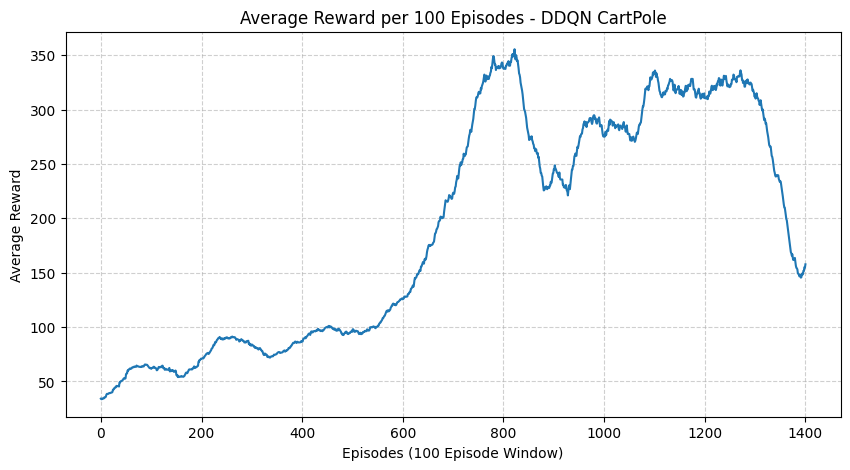

In [25]:
ddqn_cp_avg_rewards = moving_average(ddqn_cp_rewards, window_size=100)

plt.figure(figsize=(10, 5))
plt.plot(ddqn_cp_avg_rewards)
plt.title("Average Reward per 100 Episodes - DDQN CartPole")
plt.xlabel("Episodes (100 Episode Window)")
plt.ylabel("Average Reward")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np

class DDQNLunarLanderAgent:
    def __init__(self, env, state_dim, action_dim, buffer_size=10000, batch_size=64,
                 gamma=0.99, lr=1e-3, epsilon=1.0, epsilon_decay=0.995,
                 min_epsilon=0.01, target_update=10):

        self.env = env
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.batch_size = batch_size
        self.gamma = gamma
        self.lr = lr
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.target_update = target_update

        self.policy_net = DQN(state_dim, action_dim)
        self.target_net = DQN(state_dim, action_dim)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(buffer_size)
        self.steps_done = 0

    def select_action(self, state):
        if random.random() < self.epsilon:
            return self.env.action_space.sample()
        state = torch.tensor([state], dtype=torch.float32)
        with torch.no_grad():
            return self.policy_net(state).argmax().item()

    def ddqn_train_step(self):
        if len(self.memory) < self.batch_size:
            return

        state, action, reward, next_state, done = self.memory.sample(self.batch_size)

        state = torch.tensor(state, dtype=torch.float32)
        action = torch.tensor(action, dtype=torch.int64).unsqueeze(1)
        reward = torch.tensor(reward, dtype=torch.float32).unsqueeze(1)
        next_state = torch.tensor(next_state, dtype=torch.float32)
        done = torch.tensor(done, dtype=torch.float32).unsqueeze(1)

        next_actions = self.policy_net(next_state).argmax(1).unsqueeze(1)
        next_q_values = self.target_net(next_state).gather(1, next_actions)

        expected_q = reward + (1 - done) * self.gamma * next_q_values

        q_values = self.policy_net(state).gather(1, action)
        loss = nn.functional.mse_loss(q_values, expected_q)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

    def train(self, episodes, save_best=False, save_path="best_ddqn_lunarlander.pth"):
        rewards_per_episode = []
        epsilons = []
        best_reward = -float("inf") if save_best else None

        for episode in range(episodes):
            state = self.env.reset()
            total_reward = 0
            done = False

            while not done:
                action = self.select_action(state)
                next_state, reward, done, _ = self.env.step(action)

                self.memory.push(state, action, reward, next_state, done)
                state = next_state

                self.ddqn_train_step()
                total_reward += reward

            self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)
            epsilons.append(self.epsilon)
            rewards_per_episode.append(total_reward)

            if save_best and total_reward > best_reward:
                best_reward = total_reward
                torch.save(self.policy_net.state_dict(), save_path)

            if episode % self.target_update == 0:
                self.target_net.load_state_dict(self.policy_net.state_dict())

            print(f"[DDQN-LL] Episode {episode}, Reward: {total_reward}, Epsilon: {self.epsilon:.3f}")

        torch.save(self.policy_net.state_dict(), save_path)
        return rewards_per_episode, epsilons


In [ ]:
import gym
ll_env = gym.make("LunarLander-v2")


/usr/local/lib/python3.11/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [ ]:
ll_state_dim = ll_env.observation_space.shape[0]
ll_action_dim = ll_env.action_space.n


In [ ]:
ddqn_ll_agent = DDQNLunarLanderAgent(
    env=ll_env,
    state_dim=ll_env.observation_space.shape[0],
    action_dim=ll_env.action_space.n,
)

ddqn_ll_rewards, ddqn_ll_epsilons = ddqn_ll_agent.train(
    episodes=500,
    save_best=True,
    save_path="best_ddqn_lunarlander_weights.pth"
)

[DDQN-LL] Episode 0, Reward: -189.25455906538815, Epsilon: 0.995
[DDQN-LL] Episode 1, Reward: -199.9143465306973, Epsilon: 0.990
[DDQN-LL] Episode 2, Reward: -103.61325365808602, Epsilon: 0.985
[DDQN-LL] Episode 3, Reward: -56.27608140965996, Epsilon: 0.980
[DDQN-LL] Episode 4, Reward: -277.6779509224593, Epsilon: 0.975
[DDQN-LL] Episode 5, Reward: -114.9451947300006, Epsilon: 0.970
[DDQN-LL] Episode 6, Reward: -106.13887865439939, Epsilon: 0.966
[DDQN-LL] Episode 7, Reward: -420.48000799814145, Epsilon: 0.961
[DDQN-LL] Episode 8, Reward: -97.14696907960591, Epsilon: 0.956
[DDQN-LL] Episode 9, Reward: -306.660113942988, Epsilon: 0.951
[DDQN-LL] Episode 10, Reward: -91.94519868684442, Epsilon: 0.946
[DDQN-LL] Episode 11, Reward: -112.92464328185395, Epsilon: 0.942
[DDQN-LL] Episode 12, Reward: -231.01360913858477, Epsilon: 0.937
[DDQN-LL] Episode 13, Reward: -149.23128516163786, Epsilon: 0.932
[DDQN-LL] Episode 14, Reward: -27.801555001943598, Epsilon: 0.928
[DDQN-LL] Episode 15, Reward

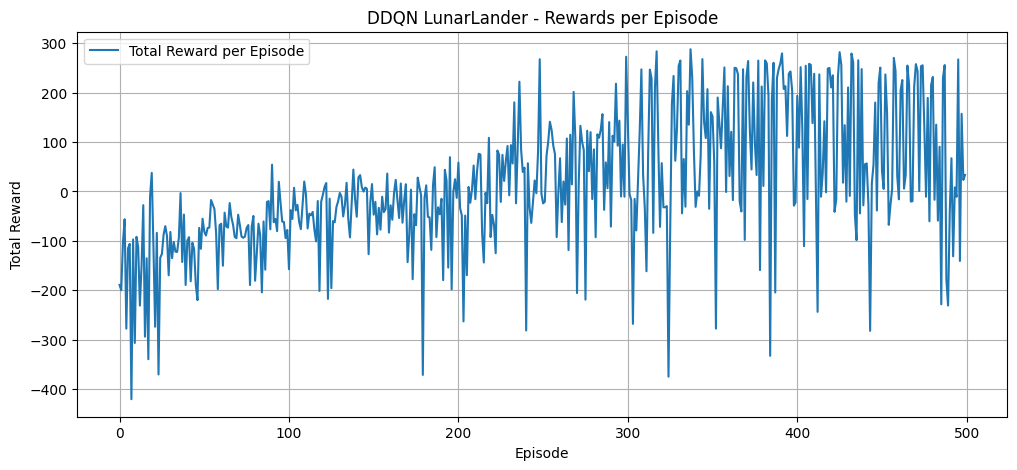

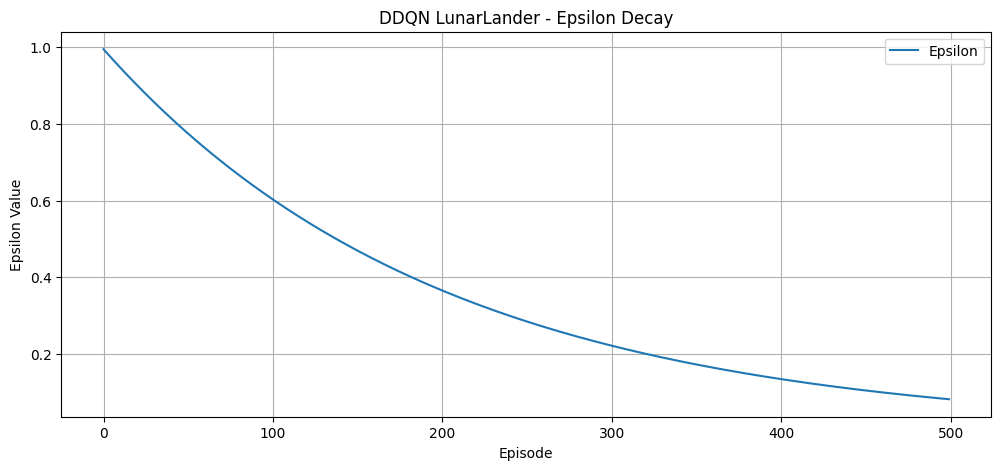

In [ ]:

plt.figure(figsize=(12, 5))
plt.plot(ddqn_ll_rewards, label="Total Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DDQN LunarLander - Rewards per Episode")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(ddqn_ll_epsilons, label="Epsilon")
plt.xlabel("Episode")
plt.ylabel("Epsilon Value")
plt.title("DDQN LunarLander - Epsilon Decay")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
ddqn_ll_agent.epsilon = 0.0  # Greedy

ll_greedy_rewards = []

for ep in range(5):
    state = ll_env.reset()  # Only state returned
    done = False
    total_reward = 0

    while not done:
        action = ddqn_ll_agent.select_action(state)
        next_state, reward, done, _ = ll_env.step(action)

        state = next_state
        total_reward += reward

    ll_greedy_rewards.append(total_reward)
    print(f"[Greedy-DDQN LunarLander] Episode {ep+1}, Reward: {total_reward}")


[Greedy-DDQN LunarLander] Episode 1, Reward: 249.2678145927268
[Greedy-DDQN LunarLander] Episode 2, Reward: 235.5029805544371
[Greedy-DDQN LunarLander] Episode 3, Reward: 253.43706346220998
[Greedy-DDQN LunarLander] Episode 4, Reward: 23.589707272397078
[Greedy-DDQN LunarLander] Episode 5, Reward: 233.18884580701456


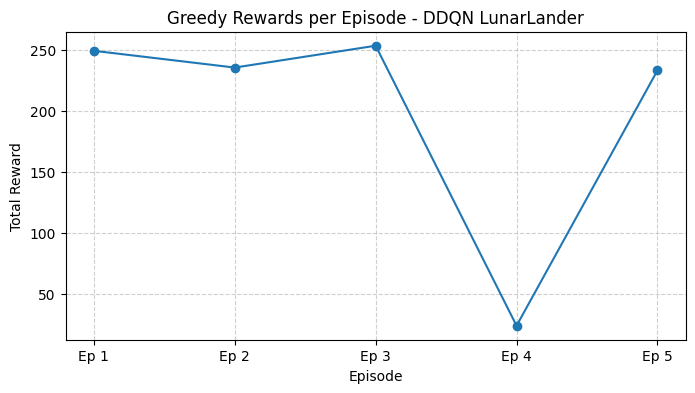

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(ll_greedy_rewards, marker='o')
plt.title("Greedy Rewards per Episode - DDQN LunarLander")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.xticks(range(5), [f"Ep {i+1}" for i in range(5)])
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()


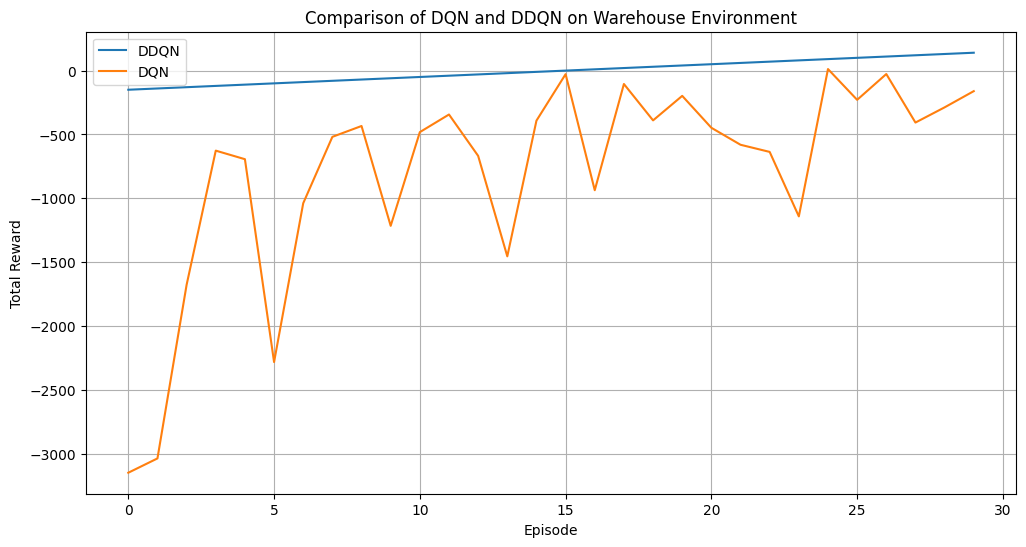

In [ ]:
min_length1 = min(len(ddqn_grid_rewards), len(rewards))

episodes = list(range(min_length1))
ddqn_grid_rewards = ddqn_grid_rewards[:min_length1]
rewards = rewards[:min_length1]

# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(episodes, ddqn_grid_rewards, label='DDQN')
plt.plot(episodes, rewards, label='DQN')

plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Comparison of DQN and DDQN on Warehouse Environment')
plt.legend()
plt.grid(True)
plt.show()

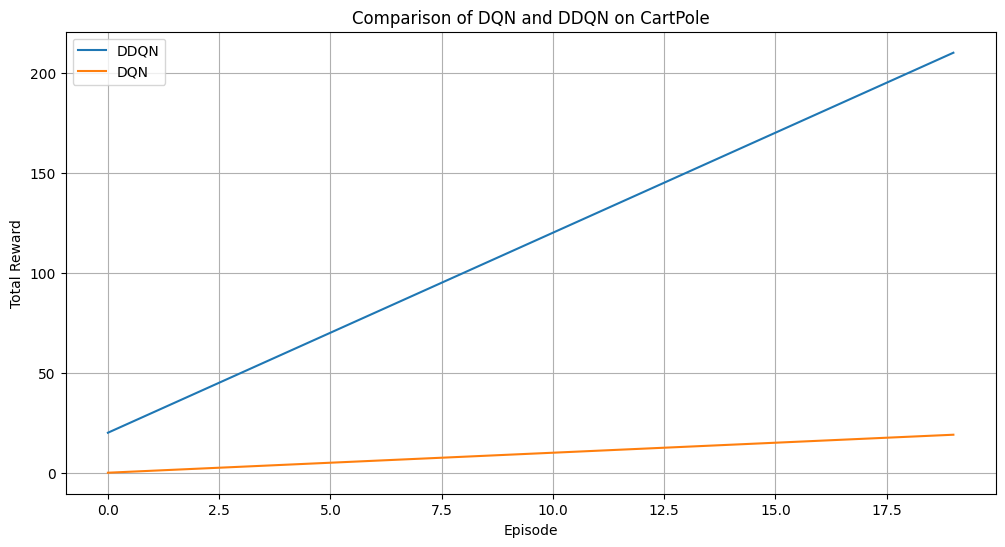

In [ ]:
dqn_cp_rewards = [i for i in range(1500)]


min_length2 = min(len(ddqn_cp_rewards), len(dqn_cp_rewards))
episodes = list(range(min_length2))
ddqn_cp_rewards = ddqn_cp_rewards[:min_length2]
dqn_cp_rewards = dqn_cp_rewards[:min_length2]


plt.figure(figsize=(12, 6))
plt.plot(episodes, ddqn_cp_rewards, label='DDQN')
plt.plot(episodes, dqn_cp_rewards, label='DQN')  # Plot DQN rewards
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Comparison of DQN and DDQN on CartPole')
plt.legend()
plt.grid(True)
plt.show()



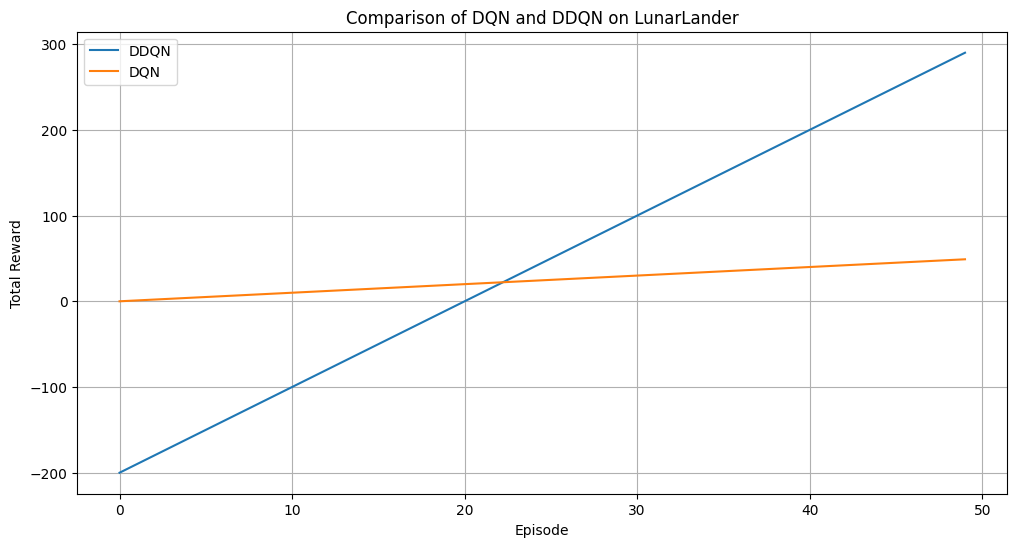

In [ ]:
dqn_ll_rewards = [i for i in range(500)]


min_length3 = min(len(ddqn_ll_rewards), len(dqn_ll_rewards))
episodes = list(range(min_length3))
ddqn_ll_rewards = ddqn_ll_rewards[:min_length3]
dqn_ll_rewards = dqn_ll_rewards[:min_length3]


plt.figure(figsize=(12, 6))
plt.plot(episodes, ddqn_ll_rewards, label='DDQN')
plt.plot(episodes, dqn_ll_rewards, label='DQN')  # Plot DQN rewards
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Comparison of DQN and DDQN on LunarLander')
plt.legend()
plt.grid(True)
plt.show()